In [2]:
#导入常用库
import sys
import pandas as pd
import os
import random
import shutil
import sklearn
import scipy
import numpy as np
import radiomics  #这个库专门用来提取特征
import SimpleITK as sitk  #读取nii文件
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV#导入Lasso工具包LassoCV
from sklearn.preprocessing import StandardScaler#标准化工具包StandardScaler
import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
model_name='model_forest1.model'

radio_datapath='data/BenignAndMalignant_v2.csv'
radio_data=pd.read_csv(radio_datapath)
radio_data.head()

,Unnamed: 0,index,Unnamed: 2,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,...,14_%,15_%,16_%,17_%,18_%,19_%,Unnamed: 1197,Unnamed: 1198,Unnamed: 1199,grade
0,0,BenignP001_L0,NaN,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",...,0.039474,0.0,0.0,0.0,0.000000,0.013158,NaN,NaN,NaN,0
1,1,BenignP002_L1,NaN,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",...,0.008955,0.0,0.0,0.0,0.023881,0.039552,NaN,NaN,NaN,0
2,2,BenignP003_L2,NaN,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",...,0.000000,0.0,0.0,0.0,0.000000,0.292453,NaN,NaN,NaN,0
3,3,BenignP003_L3,NaN,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",...,0.000000,0.0,0.0,0.0,0.000000,0.150407,NaN,NaN,NaN,0
4,4,BenignP003_L4,NaN,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",...,0.098039,0.0,0.0,0.0,0.000000,0.039216,NaN,NaN,NaN,0


1    496
0    235
Name: grade, dtype: int64


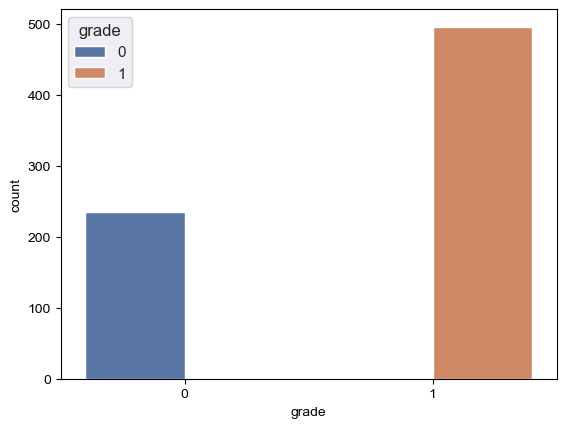

In [4]:
# 查看总数据类别是否平衡
fig, ax = plt.subplots()
sns.set()
ax = sns.countplot(x='grade',hue='grade',data=radio_data)
print(radio_data['grade'].value_counts())

In [17]:
from pandas.core.common import random_state

#查看总体数据情况
print("一共有{}行特征数据".format(radio_data.shape[0]))
print("一共有{}列不同特征".format(radio_data.shape[1]))
#再把特征值数据和标签数据分开
x1=radio_data[radio_data.columns[3:-46]]
x2=radio_data[radio_data.columns[-23:-4]]

x1 = x1.reset_index(drop=True)
x2 = x2.reset_index(drop=True)
x = pd.concat([x1, x2], axis=1)
y = radio_data['grade']
# 取X的5行看看数据
x.head()

一共有731行特征数据
一共有1201列不同特征


,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,10_%,11_%,12_%,13_%,14_%,15_%,16_%,17_%,18_%,19_%
0,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",f1ab6dff270932745181cea61f8ea223831a5193,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,0.006579,0.0,0.000000,0.0,0.039474,0.0,0.0,0.0,0.000000,0.013158
1,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",84a458099e0102df3e80681388b18c0d950b2364,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,0.010448,0.0,0.038806,0.0,0.008955,0.0,0.0,0.0,0.023881,0.039552
2,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",72821f7610d609a27715f0ae9ede7e2522acd3bf,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,0.001179,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.292453
3,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",72821f7610d609a27715f0ae9ede7e2522acd3bf,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.150407
4,v3.1.0,1.21.6,2.1.1,1.3.0,3.7.11,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",72821f7610d609a27715f0ae9ede7e2522acd3bf,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,0.000000,0.0,0.000000,0.0,0.098039,0.0,0.0,0.0,0.000000,0.039216


In [18]:
# 区分训练集和测试集
from sklearn.model_selection import train_test_split
from sklearn import datasets
seed=6677
# 30%用于测试集，70%用于训练集
X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=seed)
pd_train=pd.DataFrame(X_train)
train_index=np.array(pd_train.index)
# np.savetxt('../../data/trian_test_csv/train.txt',train_index.astype('int'))
#
# pd_test=pd.DataFrame(X_test)
# test_index=np.array(pd_test.index)
# np.savetxt('../../data/trian_test_csv/test.txt',test_index.astype('int'))
# 打印验证是否随机
print(train_index)

[146 612 220 420 246  81  65   1 328  90 400 488 481  58 158 241  19 143
 661 230 283  53 115  87  86 237 427 431 452  54 432 234 590 485 310 495
  11 608 300 466 222 474 464 660 112 467 171 606 320 714 301 710 556 267
 325 210  89 189 207  93 214 647 673 422 579 513 272 137 633 174 243  28
 483 499 410  10 615 655 180 645 224 543 477 157 471 443 609 503 166 637
 378  23 136 282 476 392 208 384 179 634 528 540 628 204 342 565  85  94
 433 285 560 381 106 173 573   4 524 229 557 343 290 585 545 697  12 428
  47 135 567 672 153 601 690 144 167 296 527 726  84 684 454 453 424 670
 155 632 475 482 298 209 699  44 195  50  98 203 611 706 362 193 473 618
 391 551 689 681 348 313 191  96 603 451 538 345 552 104 131  22 216 461
 350 613 679 515 159 620 663 605 151   3  26 648 369 580 349 305 456 181
 235 223 311 650   8 375 291 705 202 408 259 463 212 492 398 721 536 497
 639 130 686 561 430 562  60 712 122 334  48 591 271 658 244 382 317  77
 396 129 693 270 437 413 156 401 114 593 308 240  7

# 特征筛选方法

In [19]:
# T检验特诊筛选

#通过T检验从106个特征筛选
from scipy.stats import levene, ttest_ind
counts = 0
columns_index =[]
# print(X_train[y_train==0])
for column_name in X_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X_train[y_train==0][column_name], X_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index.append(column_name)
        else:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue

print("筛选后剩下的特征数：{}个".format(len(columns_index)))

diagnostics_Versions_Numpy
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_SimpleITK
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_PyWavelet
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_Python
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Settings
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Enabled

In [20]:
print(columns_index)

['diagnostics_Mask-original_VoxelNum', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy', 'original_firstorder_Variance', 'original_glrlm_Gr

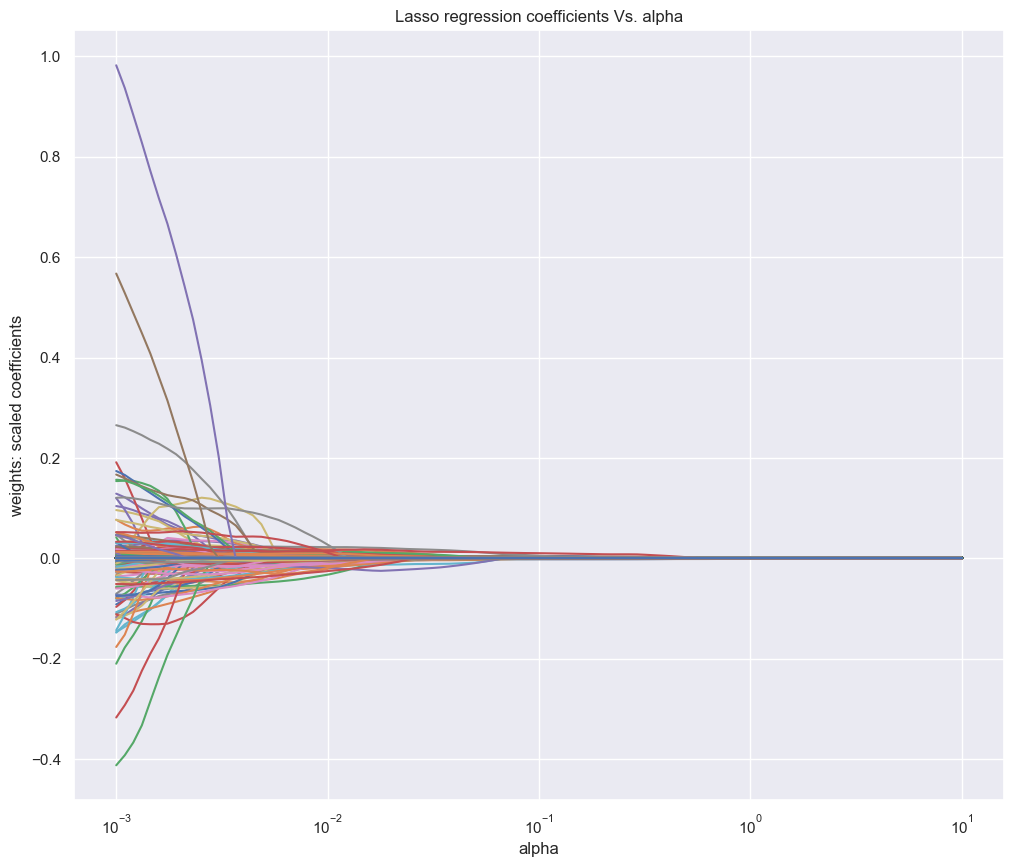

In [21]:
from sklearn.linear_model import Lasso
alpha_lasso = 10**np.linspace(-3,1,100)
lasso = Lasso()
coefs_lasso = []

for i in alpha_lasso:
    lasso.set_params(alpha = i)
    lasso.fit(X_train.loc[:,columns_index], y_train)
    coefs_lasso.append(lasso.coef_)

plt.figure(figsize=(12,10))
ax = plt.gca()
ax.plot(alpha_lasso, coefs_lasso)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights: scaled coefficients')
plt.title('Lasso regression coefficients Vs. alpha')
# plt.legend(y)
plt.show()

In [22]:
# coef = pd.Series(Lasso.coef_, index=columns_index)
# print(coef[coef !=0])

In [23]:
#再把特征值数据和标签数据分开
x = X_train.loc[:,columns_index]
y = y_train
#先保存X的列名
columnNames = x.columns

lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y

standardscaler = StandardScaler()
lassoCV_x = standardscaler.fit_transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式

# 形成5为底的指数函数
# 5**（-3） ~  5**（-2）
alpha_range = np.logspace(-3,-2,50,base=5)
#alpha_range在这个参数范围里挑出aplpha进行训练，cv是把数据集分5分，进行交叉验证，max_iter是训练1000轮
lassoCV_model = LassoCV(alphas=alpha_range,cv=5,max_iter=100)
#进行训练
lassoCV_model.fit(lassoCV_x,lassoCV_y)

#打印训练找出来的入值
print(lassoCV_model.alpha_)
# print("Coefficient of the model:{}".format(lassoCV_model.coef_) )
# print("intercept of the model:{}".format(lassoCV_model.intercept_))

coef = pd.Series(lassoCV_model.coef_, index=columnNames)
print("从原来{}个特征，筛选剩下{}个".format(len(columnNames),sum(coef !=0)))
print("分别是以下特征")
print(coef[coef !=0])
index = coef[coef !=0].index
lassoCV_x = lassoCV_x[index]
# lassoCV_x.head()

0.008
从原来731个特征，筛选剩下98个
分别是以下特征
original_shape_Maximum2DDiameterSlice     0.044778
original_shape_Maximum3DDiameter          0.013105
original_shape_SurfaceVolumeRatio        -0.021139
original_firstorder_Energy               -0.001369
original_firstorder_InterquartileRange    0.012645
                                            ...   
12_%                                      0.053125
15_%                                      0.024759
16_%                                     -0.001002
17_%                                      0.056447
18_%                                      0.038929
Length: 98, dtype: float32


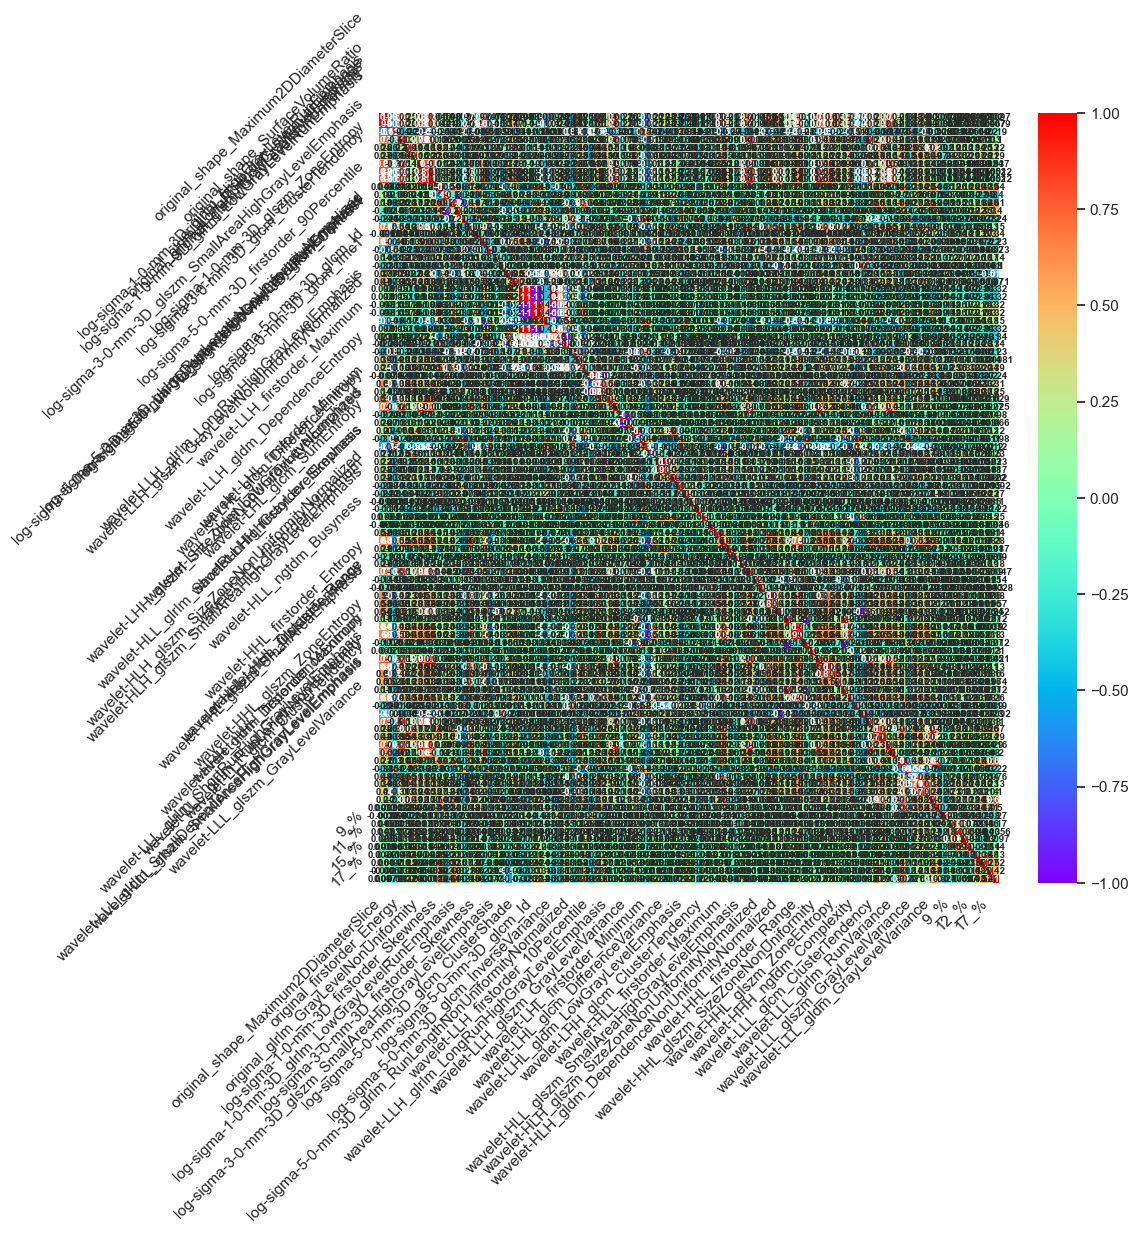

In [24]:
#绘制特征相关系数热力图
import seaborn as sns

# 根据相关性筛选
# corr_matix=lassoCV_x.corr()
# # m=~(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # n=(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # raw=corr_matix.loc[m,m]
# # raw_n=corr_matix.loc[n,n]
# # raw_n
# def count_high_corr(matirx, high_corr, threshold=0.5):
#     for i in range(matirx.shape[0]):
#         np_raw=np.array(matirx.iloc[i,:])
#         result=np.argwhere(np.abs(np_raw)>threshold).tolist()
#         result=[int(i[0]) for i in result]
#         high_corr[i]=len(result)
#     return high_corr
#
# hash_map=np.array(range(corr_matix.shape[0]))
# Flag=True
# high_corr=np.ones_like(hash_map)
# # corr_matix=np.array(corr_matix)
# r_list=[]
# while Flag:
#     origin_high_count=count_high_corr(corr_matix,high_corr)
#     # print(corr_matix.shape)
#     result=np.argmax(origin_high_count)
#     depend=np.max(origin_high_count)
#     if depend==1:
#         Flag=False
#         break
#     r_list.append(result)
#     # print(result)
#     high_corr[result]=0
#     # print(high_corr)
#     corr_matix.iloc[result,:]=0
#     corr_matix.iloc[:,result]=0
#     # print(corr_matix.shape)
#     # corr_matix.head()
#
# hash_map=np.delete(hash_map,r_list)
# corr_matix=lassoCV_x.corr().iloc[hash_map,hash_map]

# 画出热力图
f, ax= plt.subplots(figsize = (10, 10))
sns.heatmap(lassoCV_x.corr(),cmap='rainbow',annot=True,annot_kws={'size':7,'weight':'bold', },ax=ax)#绘制混淆矩阵
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,va="top",ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
plt.show()


In [25]:
# index=corr_matix.index
# lassoCV_x = lassoCV_x[index]
# coef = coef.loc[index]
# print(coef.shape)

In [26]:
weight = coef[np.abs(coef)>0.02].to_dict()

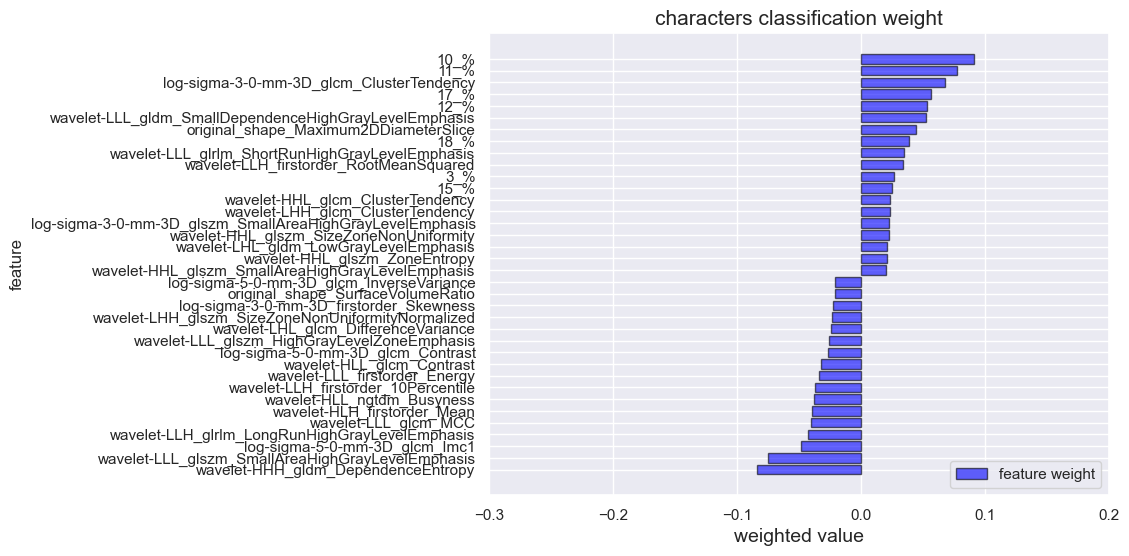

,0
wavelet-HHH_gldm_DependenceEntropy,-0.084153
wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis,-0.074652
log-sigma-5-0-mm-3D_glcm_Imc1,-0.048686
wavelet-LLH_glrlm_LongRunHighGrayLevelEmphasis,-0.042695
wavelet-LLL_glcm_MCC,-0.040064
wavelet-HLH_firstorder_Mean,-0.039753
wavelet-HLL_ngtdm_Busyness,-0.038124
wavelet-LLH_firstorder_10Percentile,-0.036623
wavelet-LLL_firstorder_Energy,-0.034086
wavelet-HLL_glcm_Contrast,-0.031905


In [27]:
#画一个特征系数的柱状图
weight = coef[np.abs(coef)>0.02].to_dict()
#根据值大小排列一下
weight = dict(sorted(weight.items(),key=lambda x:x[1],reverse=False))
plt.figure(figsize=(8,6))#设置画布的尺寸
plt.title('characters classification weight',fontsize=15)#标题，并设定字号大小
plt.xlabel(u'weighted value',fontsize=14)#设置x轴，并设定字号大小
plt.ylabel(u'feature')
plt.barh(range(len(weight.values())), list(weight.values()),tick_label = list(weight.keys()),alpha=0.6, facecolor = 'blue', edgecolor = 'black', label='feature weight')
plt.xlim([-0.3,0.2])
plt.legend(loc=4)#图例展示位置，数字代表第几象限
plt.show()
pd_weight=pd.DataFrame(coef[np.abs(coef)>0.02])
pd_weight=pd_weight.sort_values(by=0)
pd_weight

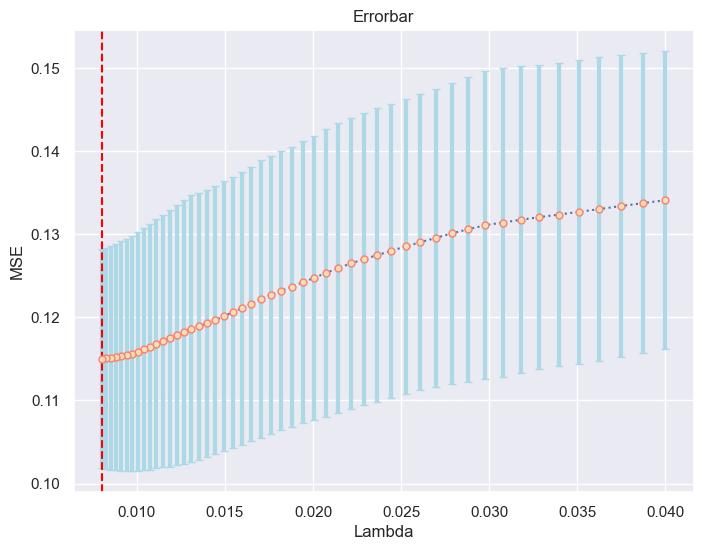

In [28]:
#绘制误差棒图
MSEs = lassoCV_model.mse_path_
mse = list()
std = list()
for m in MSEs:
    mse.append(np.mean(m))
    std.append(np.std(m))

plt.figure(figsize=(8,6))
plt.errorbar(lassoCV_model.alphas_, mse, std,fmt='o:',ecolor='lightblue',
			elinewidth=3,ms=5,mfc='wheat',mec='salmon',capsize=3)
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.title('Errorbar')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.show()

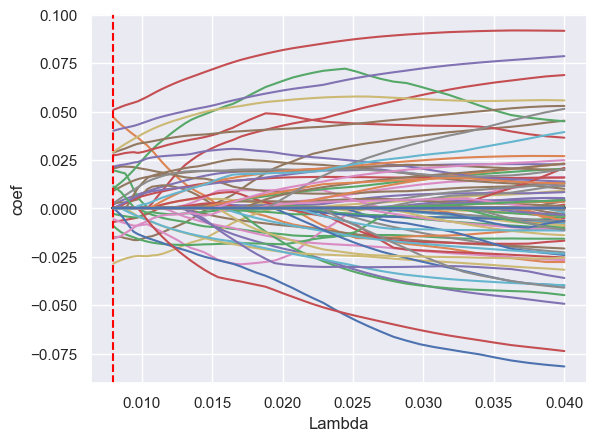

In [29]:
#再把特征值数据和标签数据分开
x = X_train.loc[:,columns_index]
y = y_train
#先保存X的列名
columnNames = x.columns
lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y
lassoCV_x = standardscaler.transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式
coefs = lassoCV_model.path(lassoCV_x,lassoCV_y, alphas=alpha_range, max_iter=1000)[1].T
plt.plot(lassoCV_model.alphas,coefs,'-')
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.xlabel('Lambda')
plt.ylabel('coef')
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay

In [31]:
from sklearn.model_selection import train_test_split #分割训练集和验证集
from sklearn.ensemble import RandomForestClassifier #导入随机森林分类器
import joblib #用来保存 sklearn 训练好的模型
#把数据分成训练集和验证集，7：3比例
index_ = pd_weight.index
rforest_x = x[index_]
rforest_y = y
standardscaler = StandardScaler()
rforest_x = standardscaler.fit_transform(rforest_x)#对x进行均值-标准差归一化
x1_train,x1_test, y1_train, y1_test = train_test_split(rforest_x,rforest_y,test_size=0.2,random_state=44)
seed=4
# model_forest = RandomForestClassifier(n_estimators=200,max_depth=13,max_features=1,random_state=seed).fit(x1_train,y1_train)
model_forest = SVC(kernel="linear", C=0.025,probability=True).fit(x1_train,y1_train)
# model_forest = MLPClassifier(alpha=0.1, max_iter=1000).fit(x1_train,y1_train)
score = model_forest.score(x1_test, y1_test)
print("在验证集上的准确率：{}".format(score))
#把随机森林的模型保存下来
model_path='./model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model_forest, model_path+'/'+model_name)

在验证集上的准确率：0.8543689320388349


['./model/model_forest1.model']

In [32]:
import joblib
index = pd_weight.index
x_test_data = pd.DataFrame(X_test.loc[:,index])

columnNames = x_test_data.columns
x_test_data = x_test_data.astype(np.float32)

x_test_data = standardscaler.transform(x_test_data) #均值-标准差归一化
x_test_data = pd.DataFrame(x_test_data,columns=columnNames)
y_test_data = pd.DataFrame(y_test)

print("测试集一共有{}行特征数据，{}列不同特征".format(len(x_test_data),x_test_data.shape[1]))
#加载保存后的模型，然后进行预测

model_forest = joblib.load(model_path+'/'+model_name) #这是自己训练模型，记得替换自己的。
score = model_forest.score(x_test_data, y_test_data)
print("在测试集上的准确率：{}".format(score))

测试集一共有220行特征数据，36列不同特征
在测试集上的准确率：0.8772727272727273


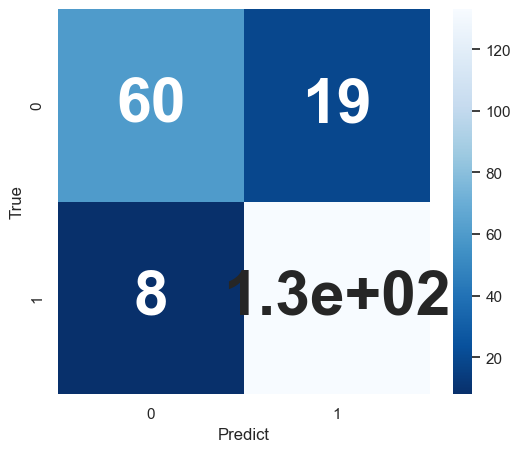

混淆矩阵为：
[[ 60  19]
 [  8 133]]

计算各项指标：
              precision    recall  f1-score   support

           0       0.88      0.76      0.82        79
           1       0.88      0.94      0.91       141

    accuracy                           0.88       220
   macro avg       0.88      0.85      0.86       220
weighted avg       0.88      0.88      0.87       220



In [33]:
#绘制混淆矩阵
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
from sklearn.metrics import confusion_matrix

predict_label = model_forest.predict(x_test_data) # 预测的标签
label = y_test_data.values.tolist()  # 真实标签
confusion = confusion_matrix(label, predict_label) # 计算混淆矩阵

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, cmap='Blues_r', annot=True, annot_kws={'size': 45, 'weight': 'bold'}) # 绘制混淆矩阵
plt.xlabel('Predict')
plt.ylabel('True')
plt.show()

print("混淆矩阵为：\n{}".format(confusion))
print("\n计算各项指标：")
print(classification_report(label, predict_label))


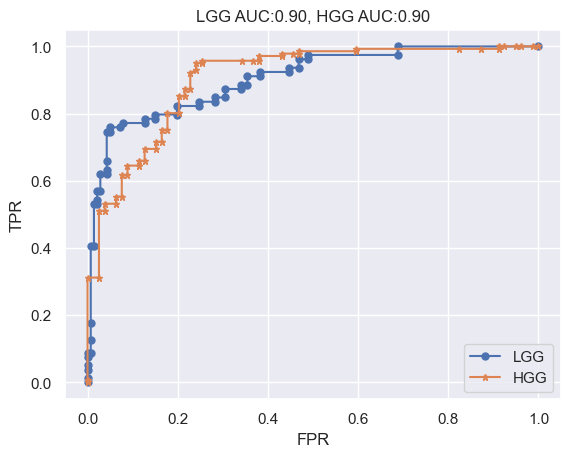

In [34]:
#绘制ROC曲线,方法1
from sklearn.metrics import roc_curve, roc_auc_score,auc
kind = {'HGG':1,"LGG":0}
model_forest = joblib.load(model_path+'/model_forest1.model')#这是自己训练模型，记得替换自己的
label = y_test_data.values.tolist()  #真实标签
y_predict = model_forest.predict_proba(x_test_data)#得到标签0和1对应的概率h
fpr , tpr ,threshold = roc_curve(label, y_predict[:,kind['LGG']], pos_label=kind['LGG'])
roc_auc = auc(fpr,tpr) #计算auc的
fpr1 , tpr1 ,threshold = roc_curve(label, y_predict[:,kind['HGG']], pos_label=kind['HGG'])
roc_auc1 = auc(fpr1,tpr1) #计算auc的
plt.plot(fpr, tpr,marker='o', markersize=5,label='LGG')
plt.plot(fpr1, tpr1,marker='*', markersize=5,label='HGG')
plt.title("LGG AUC:{:.2f}, HGG AUC:{:.2f}".format(roc_auc,roc_auc1))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc=4)
plt.show()

In [35]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
import warnings


names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]
seed=4
classifiers = [
    KNeighborsClassifier(2),
    SVC(kernel="linear", C=0.025,probability=True,random_state=seed),
    SVC(gamma=2, C=1,probability=True,random_state=seed),
    GaussianProcessClassifier(1.0 * RBF(1.0),random_state=seed),
    DecisionTreeClassifier(max_depth=5,random_state=seed),
    RandomForestClassifier(max_depth=5, n_estimators=100, max_features=10,random_state=seed),
    MLPClassifier(alpha=1, max_iter=1000,random_state=seed),
    AdaBoostClassifier(random_state=seed),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(rforest_x, rforest_y)
    pred_y= clf.predict(x_test_data)
    pred_y_proba = clf.predict_proba(x_test_data)
    accuracy=metrics.accuracy_score(y_test_data,pred_y)
    balanced_accuracy=metrics.balanced_accuracy_score(y_test_data,pred_y)
    f1_weighted=metrics.f1_score(y_test_data,pred_y)
    precision=metrics.precision_score(y_test_data,pred_y)
    sensitivity=metrics.precision_score(y_test_data,pred_y)
    tn,fp,fn,tp=confusion_matrix(y_test_data,pred_y).ravel()
    specificity=tn/(tn+fp)
    AUC=metrics.roc_auc_score(y_test_data,pred_y_proba[:,-1])
    print(name+'\n'+'accuracy: '+str(accuracy)[:6]
          +', sensitivity: '+str(sensitivity)[:6]
          +', specificity: '+str(specificity)[:6]
          +', precision: '+str(precision)[:6]
          +', f1_weighted: '+str(f1_weighted)[:6]
          +', AUC: '+str(AUC)[:6])
    # print(pred_y)
    # break
    # print(name+' '+str(score))

Nearest Neighbors
accuracy: 0.8181, sensitivity: 0.904, specificity: 0.8481, precision: 0.904, f1_weighted: 0.8496, AUC: 0.8635
Linear SVM
accuracy: 0.8590, sensitivity: 0.8481, specificity: 0.6962, precision: 0.8481, f1_weighted: 0.8963, AUC: 0.9157
RBF SVM
accuracy: 0.8454, sensitivity: 0.8057, specificity: 0.5696, precision: 0.8057, f1_weighted: 0.8924, AUC: 0.9029
Gaussian Process
accuracy: 0.6409, sensitivity: 0.6409, specificity: 0.0, precision: 0.6409, f1_weighted: 0.7811, AUC: 0.8712
Decision Tree
accuracy: 0.8045, sensitivity: 0.8450, specificity: 0.7215, precision: 0.8450, f1_weighted: 0.8480, AUC: 0.7891
Random Forest
accuracy: 0.8681, sensitivity: 0.8733, specificity: 0.7594, precision: 0.8733, f1_weighted: 0.9003, AUC: 0.9197
Neural Net
accuracy: 0.8681, sensitivity: 0.8943, specificity: 0.8101, precision: 0.8943, f1_weighted: 0.8975, AUC: 0.9296
AdaBoost
accuracy: 0.8909, sensitivity: 0.9333, specificity: 0.8860, precision: 0.9333, f1_weighted: 0.9130, AUC: 0.9201
Naive B

In [ ]:
index = pd_weight.index
rforest_x = X_train.loc[:,index]
rforest_x['label']=y_train
rforest_x.to_csv('model_data/train.csv')
x_test_data = X_test.loc[:,index]
x_test_data['label']=y_test_data
x_test_data.to_csv('model_data/test.csv')